In [2]:
import os
#import eigen
import multiprocess as mp
from tqdm import tqdm
from quspin.tools.lanczos import lanczos_full,expm_lanczos
from quspin.operators import hamiltonian
from quspin.basis import boson_basis_1d
import matplotlib.pyplot as plt
import numpy as np 


In [3]:
os.environ['OMP_NUM_THREADS'] = '22'
os.environ['OPENBLAS_NUM_THREADS'] = '22'
os.environ['MKL_NUM_THREADS'] = '22'

In [5]:
L = 12
N = L 
nb = 0.5
sps = 3
#int(nb*L+1)

basis = boson_basis_1d(L,nb=nb,sps=sps)
D = basis.Ns


print("Basis dimension: ",basis.Ns,"\n")

Basis dimension:  8074 



In [8]:
no_checks = dict(check_herm=False,check_symm=False,check_pcon=False)

def full(psi,psi_i):

    catch_out = []
    batch_size = 100
    batch_states = np.array_split(psi,batch_size,axis=1)

    for j in tqdm(range(batch_size)):

        psi_batch = np.array(batch_states[j])

        
        if j==0:
            catch_out = list(np.absolute(np.einsum('kl,l->k',np.conjugate(psi_batch.T),psi_i))**2)
        else:
            catch_out.extend(np.absolute(np.einsum('kl,l->k',np.conjugate(psi_batch.T),psi_i))**2)

    return np.asarray(catch_out)


def calc_prob(psi,ns,string):

    def site_project(psi_r,rung,p):

        norm = 1
        for alpha in range(0,sps):

            if alpha!=p:

                pr_ir = hamiltonian([["n",[[-1,rung]]],["I",[[alpha,rung]]]],[],basis=basis,**no_checks)
                psi_r = pr_ir.dot(psi_r)
                norm = norm*(alpha-p)

        return psi_r/norm


    def site_average(i,queue,psi_batch):

        init_str = np.array([char for char in string])
        
        if i+ns <= L:

            n = 0
            rung_psi_r = np.copy(psi_batch)

            while  n<=ns-1:

                rung_psi_r = site_project(rung_psi_r,(i+n),int(init_str[(i+n)]))
                n+=1

            queue.put(np.einsum('kl,lk->k',np.conjugate(psi_batch.T),rung_psi_r).real)


    sites = np.arange(0,N,1)
    avlst,catch_out = [],[]
    batch_size = 100
    batch_states = np.array_split(psi,batch_size,axis=1)
    
    processes = []
    queue = mp.Queue()

    for j in tqdm(range(batch_size)):
        
        for i in range(N):
            process = mp.Process(target=site_average, args=(i,queue,np.array(batch_states[j])))
            processes.append(process)
            process.start()

        for process in processes: process.join()    


        while not queue.empty():
            catch_out.append(queue.get())
            
        processes = []
        

        if j == 0:
            avlst = list(np.mean(np.array(catch_out),axis=0))
        else:
            avlst.extend(np.mean(np.array(catch_out),axis=0))
        
        catch_out = []

    return avlst


In [9]:

############################ Hamiltonian ##############################

U = 1.0
V = 0.0 
J_par = 1.0
J_perp = 0.0
delta = 0.0

int_list_0_p = [[0.5*delta*(-1)**i,i] for i in range(N)]
int_list_1_p = [[-0.5*U,i] for i in range(N)]
int_list_2_p = [[0.5*U,i,i] for i in range(N)]

v_lst = [[V,i,(i+1)] for i in range(N-1)]
hop_list_p = [[-J_par,i,(i+1)] for i in range(N-1)]
hop_list_hc_p = [[J.conjugate(),i,j] for J,i,j in hop_list_p]
hop_list_per = [[-J_perp,i,(i+2)] for i in range(N-2)]
hop_list_hc_per = [[J.conjugate(),i,j] for J,i,j in hop_list_per]


static_p = [
            ["+-",hop_list_p],
            ["-+",hop_list_hc_p],
            ["nn",int_list_2_p],
            ["nn",v_lst],
            ["n",int_list_1_p],
            ["n",int_list_0_p]
           ]

dynamic = []

H = hamiltonian(static_p,[],basis=basis,**no_checks,dtype=np.float32)

print("\nStarting diagonalization\n")


Starting diagonalization



In [14]:
F,V = np.linalg.eigh(H.todense())

In [15]:
dEtab = [F[i+1]-F[i] for i in range(D-1)]
offset = 0
tol = 1e-14
for i in range(len(dEtab)-1):
    if dEtab[i-offset]<tol:
        del(dEtab[i-offset])

    offset+=1


meanlevspace = np.mean(dEtab)
sigma = meanlevspace

In [26]:

def dos(e):
    return np.sum(np.exp(-((F-e)**2)/(2*sigma**2))*(1/(np.sqrt(2*np.pi)*sigma)))
dosv = np.vectorize(dos)
def calibrate(string,n):

    global energy 
    psi_i = np.zeros(basis.Ns,dtype=np.float32)
    psi_i[basis.index(string)] = 1.0

    energy = H.expt_value(psi_i)
    print("\n","Energy density = ",energy/L,"\n")

    omega = dosv(F)

    with open("dos_L"+str(L)+".out",'w') as f:
        np.savetxt(f, omega, delimiter=',')

#    plt.semilogy(F,omega,'o')
#    plt.axvline(x=energy,linestyle='dashed',color='black',zorder=10)
#    plt.show()

    if n<L:

        p = calc_prob(V,n,string)

    elif n == L:

        p = full(V,psi_i)

    return F/L,p


In [27]:

def time_average():
       
    state_str = '1100'

    msr_str1 = state_str

    psi_i = np.zeros(basis.Ns,dtype=np.float32)
    psi_i[basis.index(state_str)] = 1.0

    energy = H.expt_value(psi_i)
    print("\n","Energy= ",energy,"\n")

    print("\nStarting lanczos:\n")
    
    dt = 0.25
    kdim = 20
    nsteps = 400

    psit_la = psi_i

    psit = np.zeros((basis.Ns,nsteps),dtype=np.float32)

    for i in range(nsteps):
        
        if i==0:
            psit[:,i] = psi_i
            
        else:

            E2,V2,Q2 = lanczos_full(H,psit_la,kdim)
            psit_la = expm_lanczos(E2,V2,Q2,a=-1j*dt)
            psit[:,i] = psit_la

        print("finished evolution till: {0:f}.".format((i+1)*dt))

    print("\nStarting expectation calculation:\n")
    
    mean2s = calc_prob(psit,2,msr_str1)
    mean4s = calc_prob(psit,4,msr_str1)
    mean6s = calc_prob(psit,6,msr_str1)
    mean8s = calc_prob(psit,8,msr_str1)

    print("\nfinished delta: {0:f}.\n".format(delta))

    return mean2s,mean4s,mean6s,mean8s


In [29]:
############################################################# full projector ED #####################

state_str = '010101010101'
e,p = calibrate(state_str,L)



 Energy density =  0.0 



100%|██████████| 100/100 [00:00<00:00, 897.72it/s]


In [36]:

e,p1 = calibrate(state_str,1)
print("\nCompleted N=",1,"\n")
e,p2 = calibrate(state_str,2)
print("\nCompleted N=",2,"\n")
e,p3 = calibrate(state_str,3)
print("\nCompleted N=",3,"\n")
e,p4 = calibrate(state_str,4)
print("\nCompleted N=",4,"\n")
e,p5 = calibrate(state_str,5)
print("\nCompleted N=",5,"\n")


 Energy density =  0.0 



100%|██████████| 100/100 [00:10<00:00,  9.27it/s]



Completed N= 1 


 Energy density =  0.0 



100%|██████████| 100/100 [00:11<00:00,  8.81it/s]



Completed N= 2 


 Energy density =  0.0 



...


Completed N= 3 


 Energy density =  0.0 



100%|██████████| 100/100 [00:11<00:00,  8.36it/s]



Completed N= 4 


 Energy density =  0.0 



100%|██████████| 100/100 [00:12<00:00,  8.12it/s]


Completed N= 5 



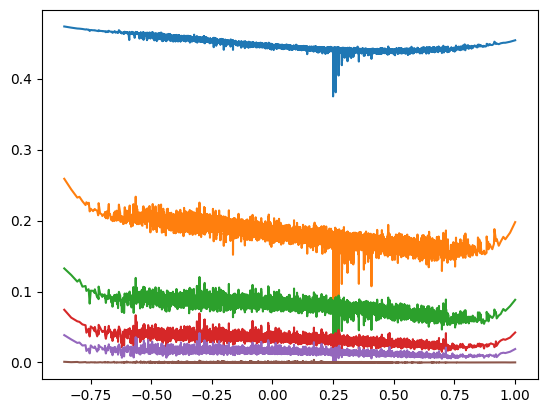

In [42]:
plt.plot(e,p1)
plt.plot(e,p2)
plt.plot(e,p3)
plt.plot(e,p4)
plt.plot(e,p5)
plt.plot(e,p)
#plt.yscale('log')